In [101]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd
import numpy as np 

In [2]:
# DIR = Path("../../artifacts/2023-06-s8/dev/accuracy-basis")
DIR = Path("../../artifacts/2023-06-s8/accuracy")

In [3]:
def load(dataset, logit_mod, arch, layer, basis_name, basis_mode):
    with open(DIR / dataset / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
        data = json.load(fh)
        
    return data

load("cifar100-people--n50", "oneclass", "cifar100-resnet18-p1", "layer3", "pca", basis_mode="centered");

In [4]:
def color(name):
    if "random" in name:
        return "lightgray"
#     elif "pca" in name:
#         return "gray"
    else:
        return None

In [5]:
coarse_labels = pd.read_csv("../../xaikd/resources/cifar100-label-mapping.csv")["coarse_label_name"].unique()

coarse_labels = sorted(coarse_labels)

coarse_labels[::4]

['aquatic_mammals',
 'fish',
 'flowers',
 'food_containers',
 'fruit_and_vegetables',
 'household_electrical_devices',
 'household_furniture',
 'insects',
 'large_carnivores',
 'large_man_made_outdoor_things',
 'large_natural_outdoor_scenes',
 'large_omnivores_and_herbivores',
 'medium_mammals',
 'non_insect_invertebrates',
 'people',
 'reptiles',
 'small_mammals',
 'trees',
 'vehicles_1',
 'vehicles_2']

In [169]:
coarse_labels[::4]



['aquatic_mammals',
 'fruit_and_vegetables',
 'large_carnivores',
 'medium_mammals',
 'small_mammals']

In [34]:
datasets = list(map(lambda x: f"cifar100-{x}", coarse_labels))

print("\n".join(datasets[::4]))

cifar100-aquatic_mammals
cifar100-fruit_and_vegetables
cifar100-large_carnivores
cifar100-medium_mammals
cifar100-small_mammals


In [171]:
selected_datasets = datasets[::4]
selected_datasets

['cifar100-aquatic_mammals',
 'cifar100-fruit_and_vegetables',
 'cifar100-large_carnivores',
 'cifar100-medium_mammals',
 'cifar100-small_mammals']

# Grid Accuracy

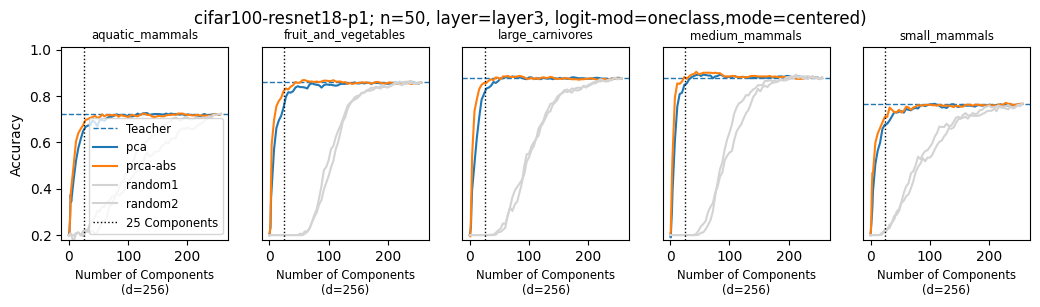

In [102]:
def grid(
    layer, arch="cifar100-resnet18-p1", logit_mod = "oneclass", nn=None, num_samples=50,
    basis_mode="centered",

    basis_names = [
        "pca",
        "prca-abs",
#         "prca-reconreg1.0", 
#         "prca-reconreg10.0", 
        "random1", "random2",
#         "random3"
    ],
    selected_datasets = datasets[::4]
):
    

    
    ncols = 5
    nrows = len(selected_datasets) // 5
    nrows = np.max([nrows, 1])
    
    plt.figure(
        figsize=(ncols * 2.5, nrows*2.5)
    )
    plt.suptitle(
        f"{arch}; n={num_samples}, layer={layer}, logit-mod={logit_mod},mode={basis_mode})",
        y=1.03
    )
    
    for dix, dataset in enumerate(selected_datasets):
        plt.subplot(nrows, ncols, dix+1)
        plt.title(dataset.split("-")[-1], fontsize="small")
        
        for bix, basis_name in enumerate(basis_names):
            data = load(f"{dataset}--n{num_samples}", logit_mod, arch, layer, basis_name, basis_mode)
            
            if bix == 0:
                plt.axhline(data["original_auroc"], ls='--', lw=1, label="Teacher")
            
            plt.plot(
                data["arr_ks"][:nn], data["arr_acc"][:nn],
                label=basis_name, color=color(basis_name)
            )
            
            
        d = data["arr_ks"][-1] 
        
#         if nn is None:
        
        K = int(0.1*d)
#         K = 6
        if nn is None:
            plt.axvline(K, ls=":", lw=1, color="k", label=f"{K} Components")
#         plt.axvline(5, ls="-", lw=1, color="k", label="10% Components")

        if dix == 0:
            plt.legend(fontsize="small")
            
        plt.ylim([0.18, 1.01])
        if dix % ncols == 0:
            plt.ylabel("Accuracy")
        else:
            plt.yticks([])
            
        last_row = dix // ncols == nrows - 1
        if last_row:
            plt.xlabel(f"Number of Components\n(d={d})", fontsize="small")
        else:
            plt.xticks([])

grid(layer="layer3")

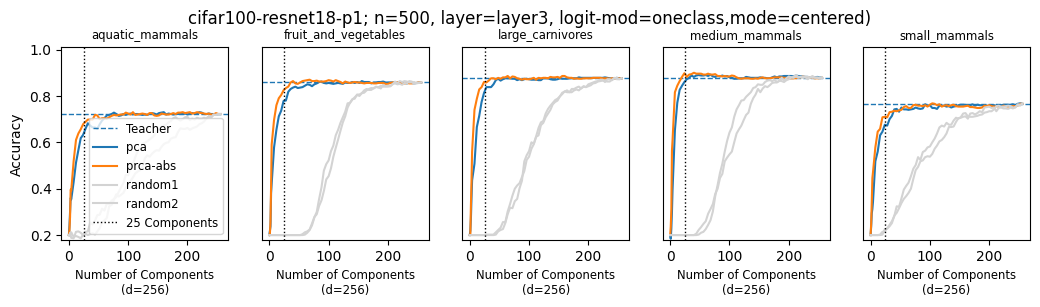

In [103]:
grid(layer="layer3", num_samples=500)

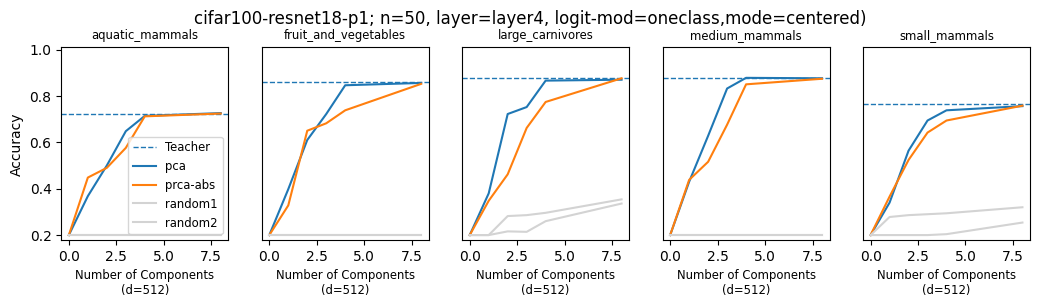

In [104]:
grid(layer="layer4", nn=6)

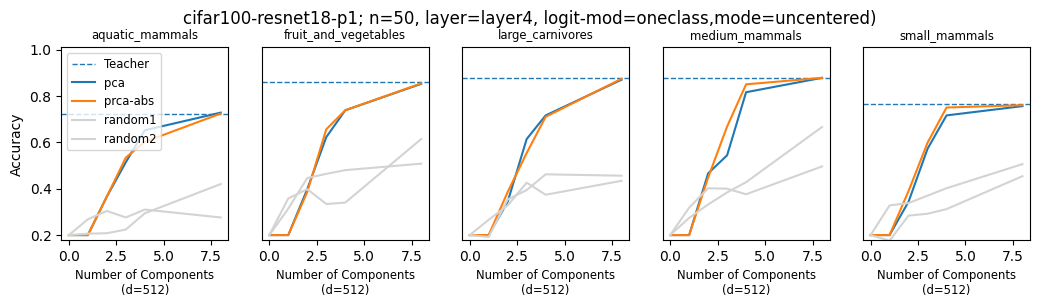

In [105]:
grid(layer="layer4", nn=6, basis_mode="uncentered")

# Compare cifar100-resnet18-p1 across layers

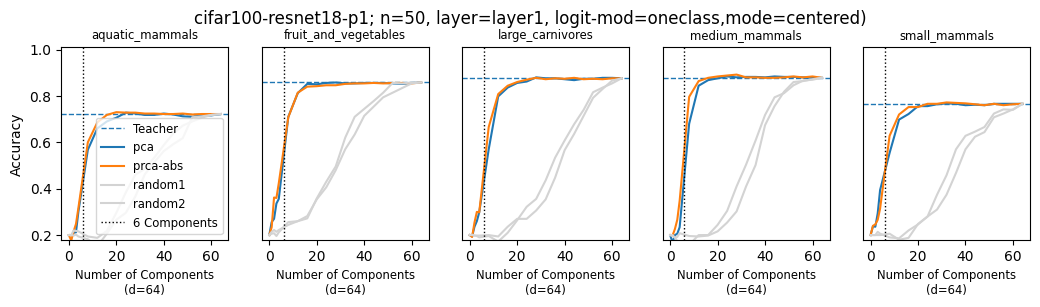

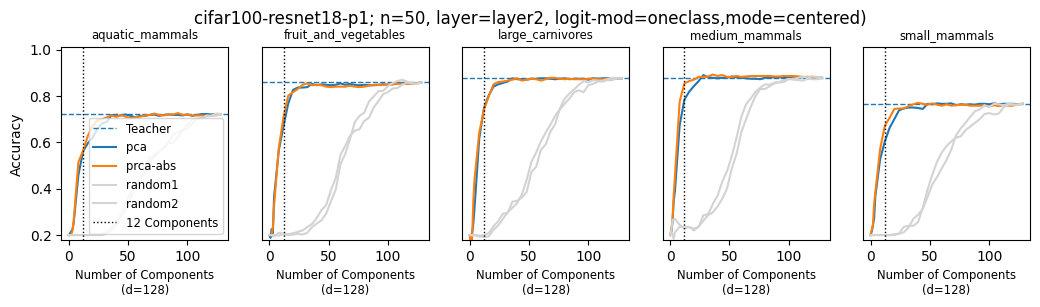

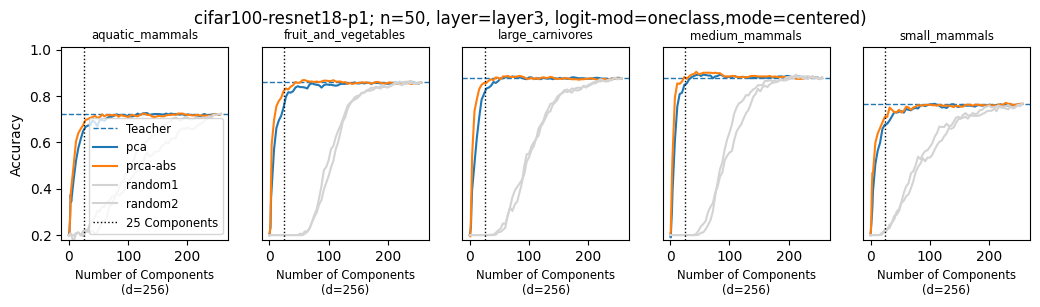

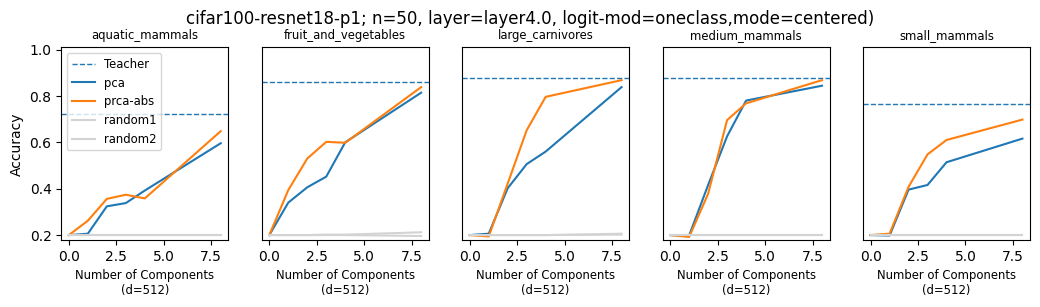

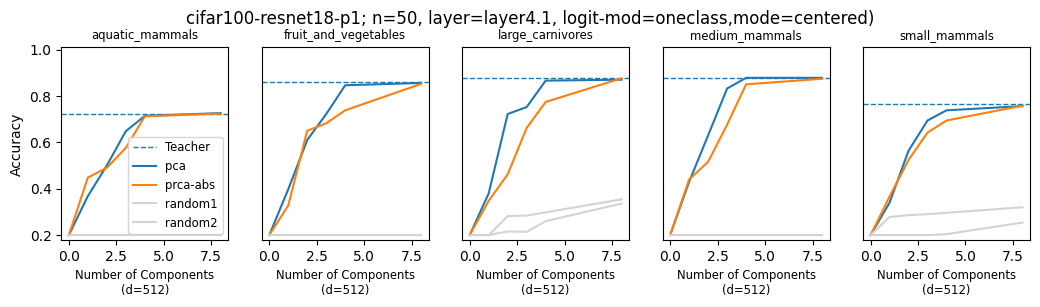

In [106]:
for layer in ["layer1", "layer2", "layer3", "layer4.0", "layer4.1"]:
    grid(
#         basis_names=["pca", "prca-abs", "pcaprca-abs"],
        layer=layer, arch="cifar100-resnet18-p1", nn=6 if "4" in layer else None, num_samples=50
    )

# Comparing Acoss different models

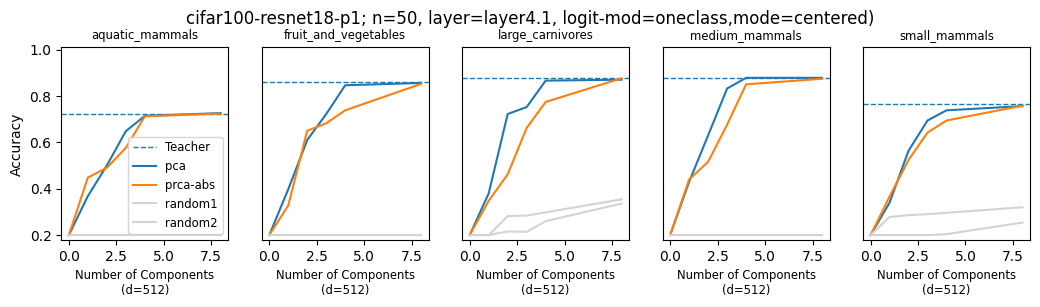

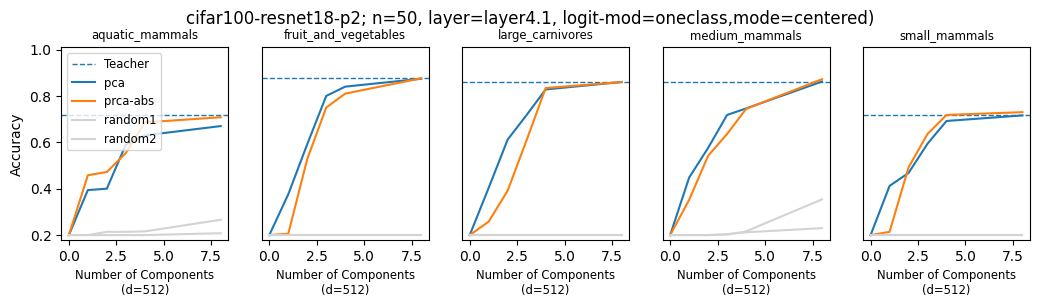

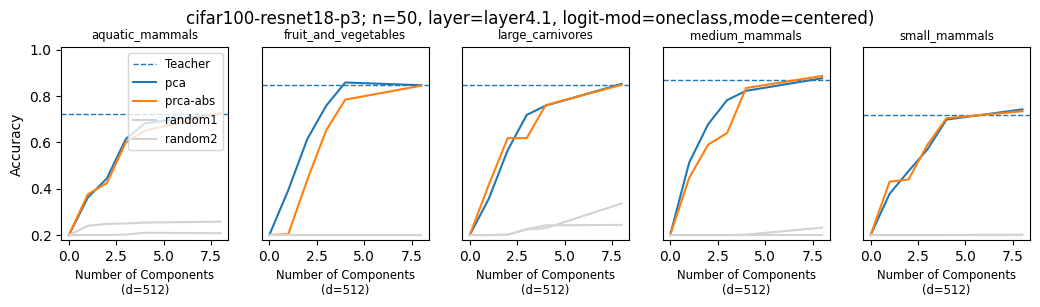

In [107]:
for arch in ["cifar100-resnet18-p1", "cifar100-resnet18-p2", "cifar100-resnet18-p3"]:
    grid(layer="layer4.1", arch=arch, nn=6, num_samples=50)

# PCAPRCA-abs

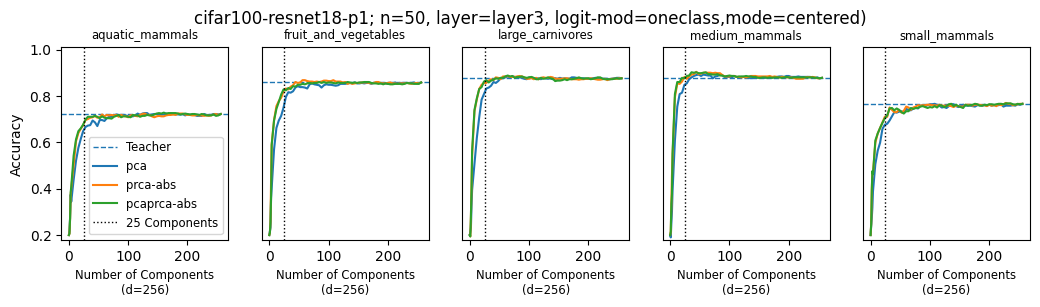

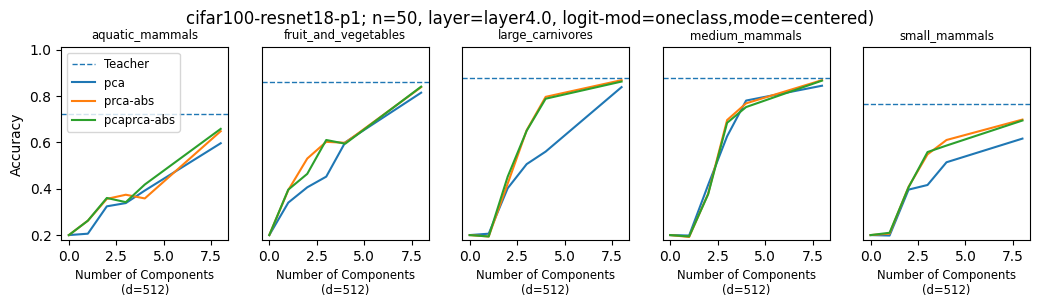

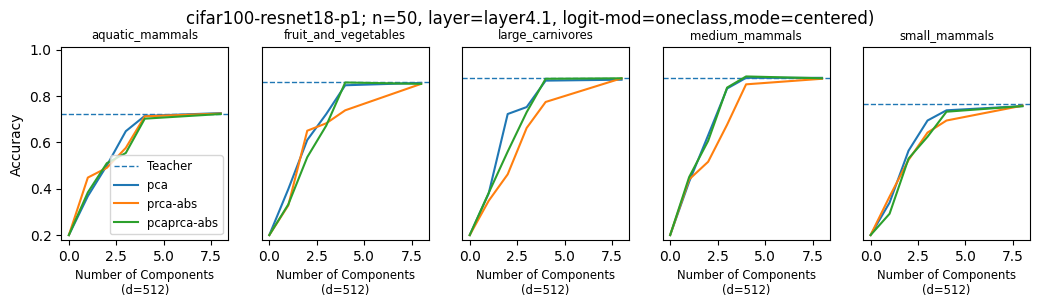

In [108]:
for layer in ["layer3", "layer4.0", "layer4.1"]:
    grid(
        basis_names=["pca", "prca-abs", "pcaprca-abs"],
        layer=layer, arch="cifar100-resnet18-p1", nn=6 if "4" in layer else None, num_samples=50
    )

# OneClassLogSumExp

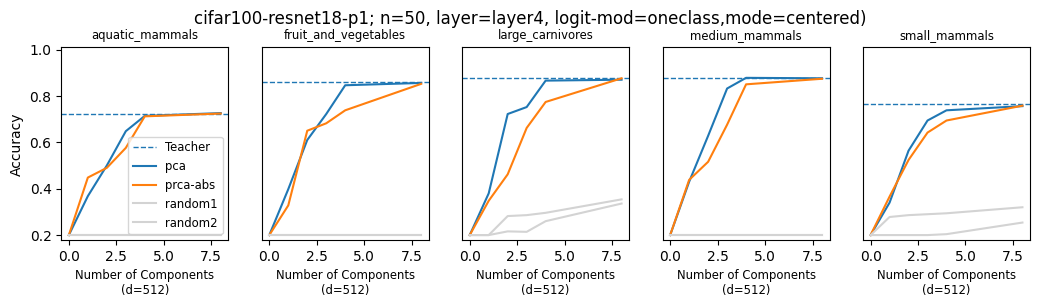

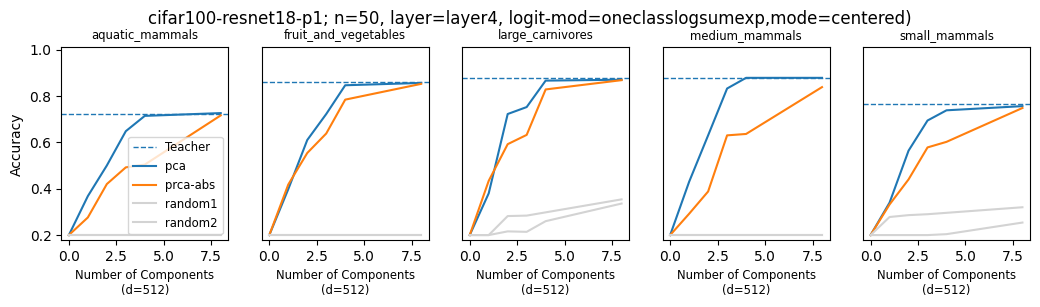

In [109]:
for logitmod in ["oneclass", "oneclasslogsumexp"]:
    grid(layer="layer4", arch="cifar100-resnet18-p1", logit_mod=logitmod, nn=6, num_samples=50)

# Resnet50

FileNotFoundError: [Errno 2] No such file or directory: '../../artifacts/2023-06-s8/accuracy/cifar100-aquatic_mammals--n50/logit-mod-oneclass/cifar100-resnet50-p1/layer2/pca--centered/stats.json'

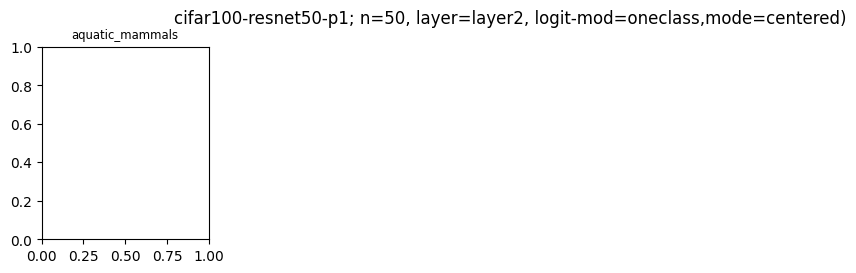

In [206]:
for layer in ["layer3", "layer4.0",  "layer4.1", "layer4.2"]:
    grid(layer=layer, arch="cifar100-resnet50-p1", nn=15, num_samples=50)

# VGG11

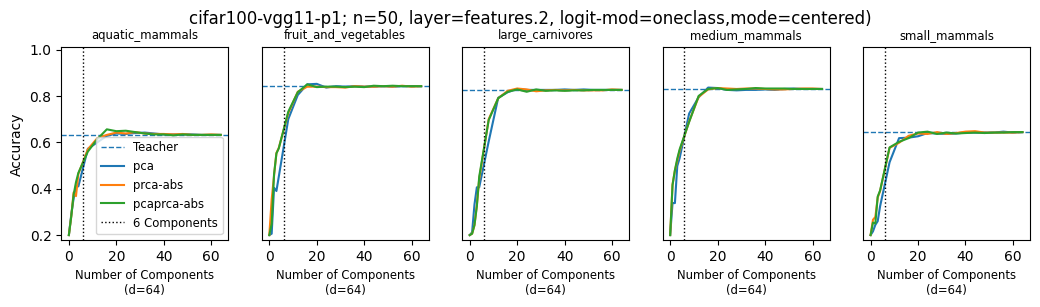

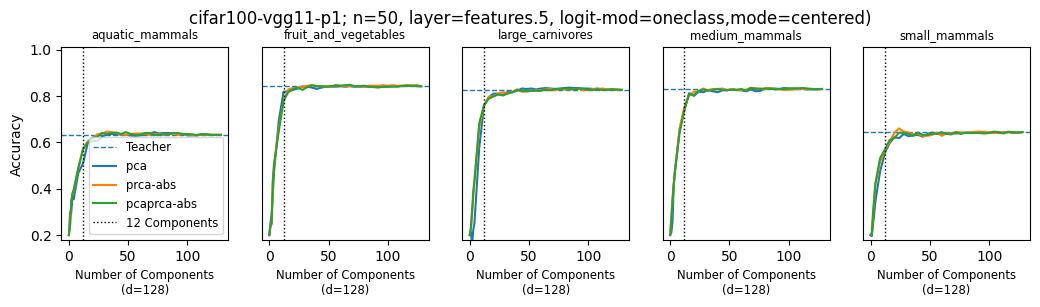

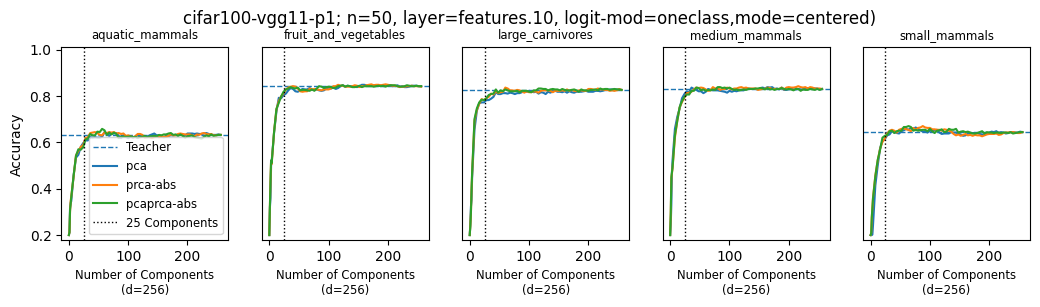

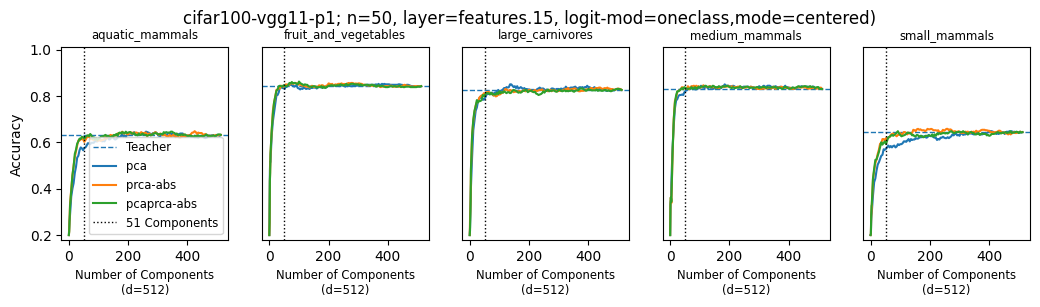

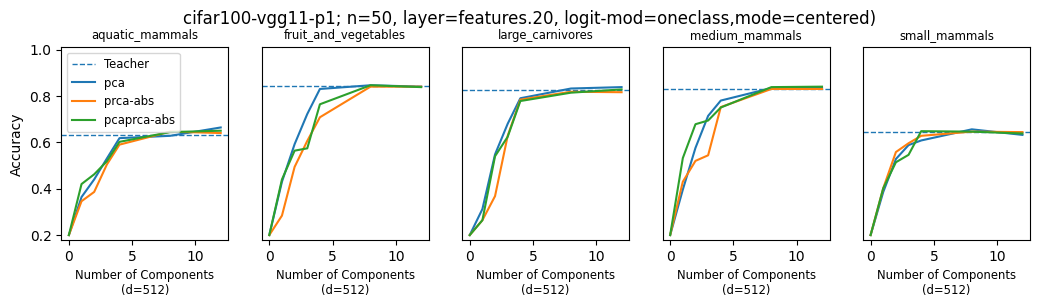

In [111]:
for layer in ["features.2", "features.5", "features.10", "features.15", "features.20"]:
    grid(
        layer=layer,
        arch="cifar100-vgg11-p1",
        basis_names=["pca", "prca-abs", "pcaprca-abs"],
        nn=7 if "20" in layer else None,
        num_samples=50
    )

# Cifar10 (SIMCLR)

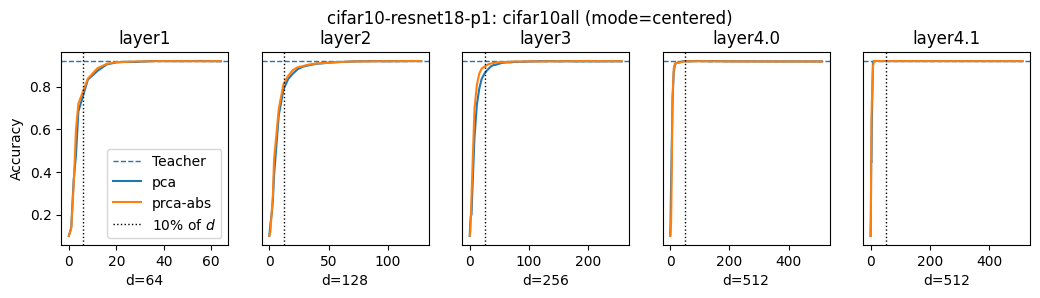

In [192]:
def viz_across_layers(arch, dataset, nn=None, layers=["layer1", "layer2", "layer3", "layer4.0", "layer4.1"]):
    num_samples = 50
    
    basis_names = ["pca", "prca-abs"]
    basis_mode = "centered"
    logit_mod = "oneclass"
    ncols = len(layers)
    nrows = 1
    
    plt.figure(figsize=(2.5*ncols, 2.5*nrows))
    plt.suptitle(f"{arch}: {dataset} (mode={basis_mode})", y=1.05)
    for lix, layer in enumerate(layers):
        plt.subplot(nrows, ncols, lix+1)
        plt.title(layer)
        for bix, basis_name in enumerate(basis_names):
            data = load(f"{dataset}--n{num_samples}", logit_mod, arch, layer, basis_name, basis_mode)
            
            if bix == 0:
                plt.axhline(data["original_auroc"], ls='--', lw=1, label="Teacher")

            plt.plot(
                data["arr_ks"][:nn], data["arr_acc"][:nn],
                label=basis_name, color=color(basis_name)
            )
      
        d = data["arr_ks"][-1] 
        K = int(0.1*d)
        
        if nn is None:
            plt.axvline(K, ls=":", lw=1, color="k", label=f"10% of $d$")

        if lix == 0:
            plt.legend()
            plt.ylabel("Accuracy")
        else:
            plt.yticks([])
            
        plt.xlabel(f"d={d}")

            
viz_across_layers("cifar10-resnet18-p1", "cifar10all")   

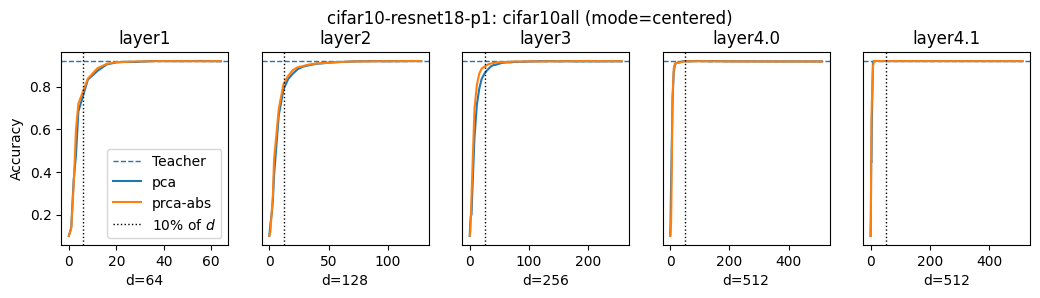

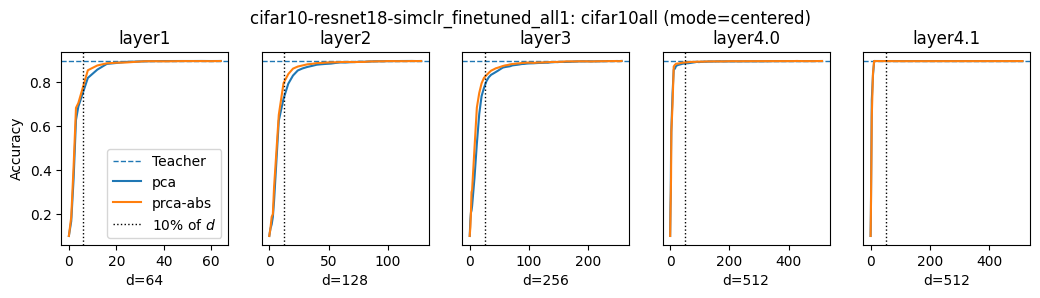

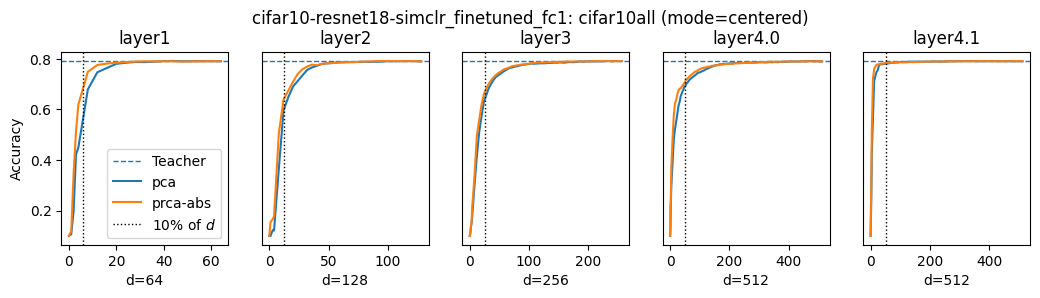

In [181]:
for arch in ["cifar10-resnet18-p1", "cifar10-resnet18-simclr_finetuned_all1", "cifar10-resnet18-simclr_finetuned_fc1"]:
    viz_across_layers(arch, "cifar10all")   

# CIFAR100 Across Layers

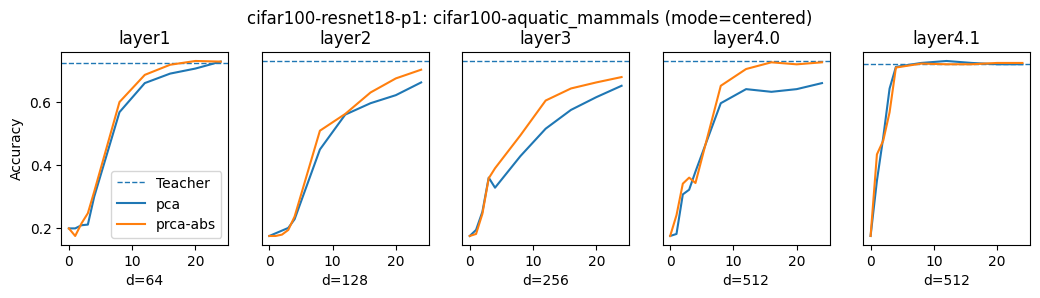

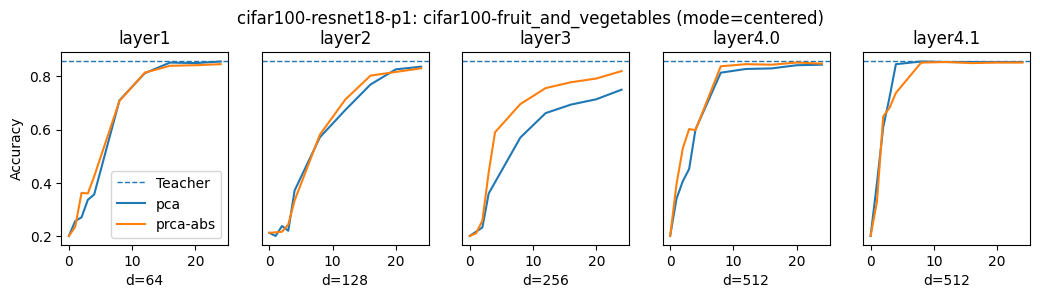

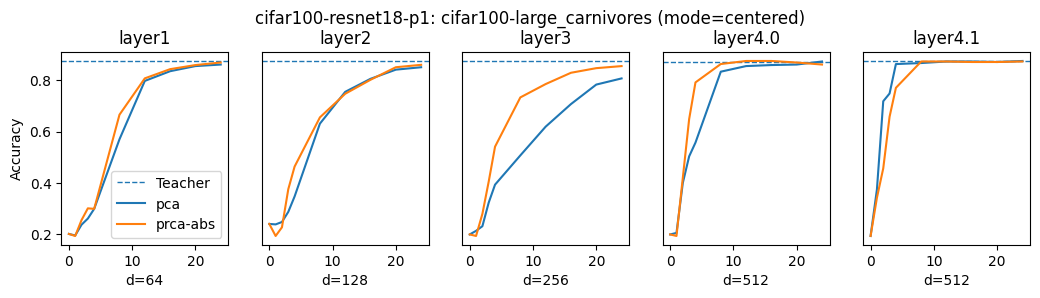

In [190]:
for dataset in selected_datasets[:3]:
#     viz_across_layers("cifar100-resnet18-p1", dataset,)   
    viz_across_layers("cifar100-resnet18-p1", dataset, nn=10,)   

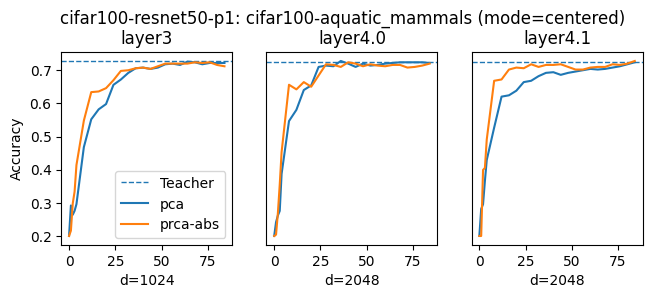

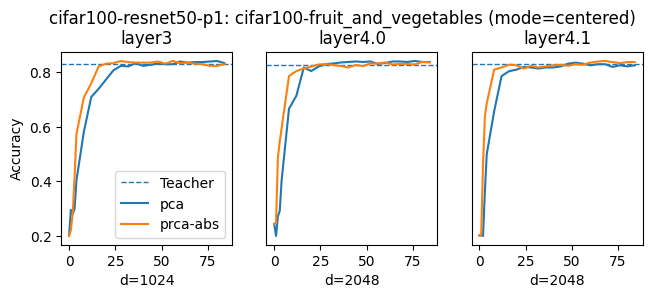

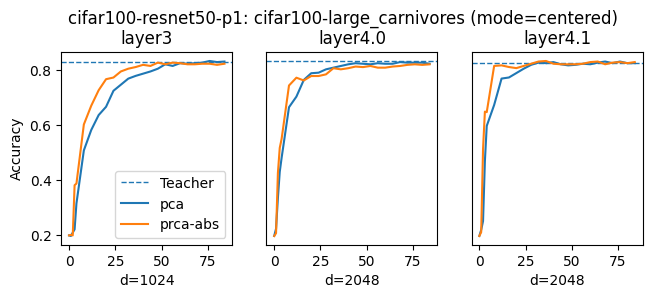

In [212]:
for dataset in selected_datasets[:3]:
    viz_across_layers("cifar100-resnet50-p1", dataset, nn=25, layers=["layer3", "layer4.0", "layer4.1"])   

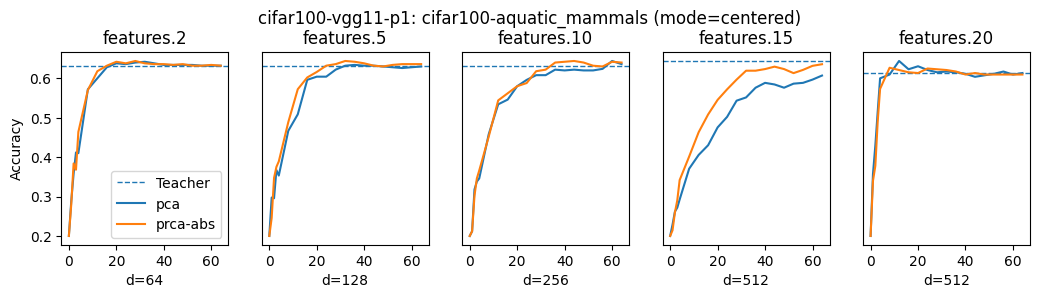

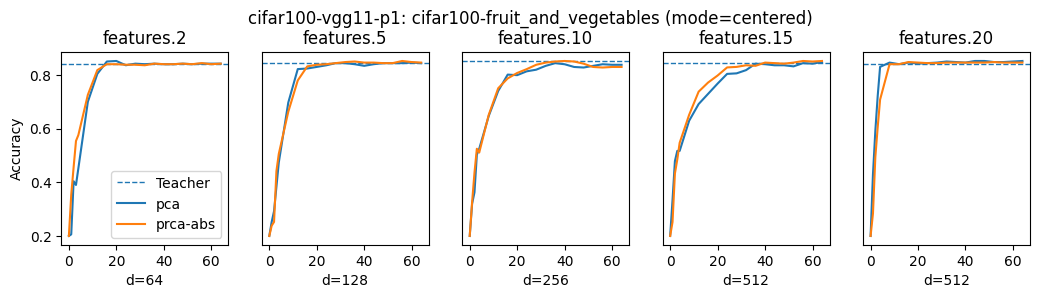

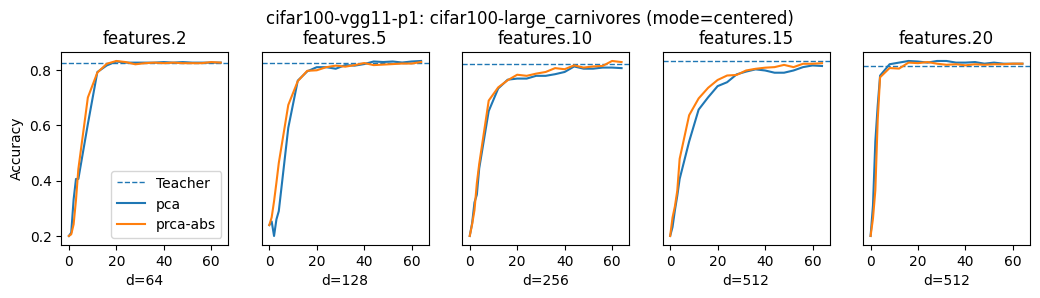

In [203]:
for dataset in selected_datasets[:3]:
    
#     viz_across_layers(
#         "cifar100-vgg11-p1", dataset,
#         layers=["features.2", "features.5", "features.10", "features.15", "features.20"]
#     )   
    viz_across_layers("cifar100-vgg11-p1", dataset, nn=20,
                      layers=["features.2", "features.5", "features.10", "features.15", "features.20"]
                     )   